
# CStats - Python Lab 9: Convolutional Neural Networks

**Libraries:** `numpy`, `matplotlib`, `scikit-learn`, `torch`.

If you are missing something, install with:
```bash
pip install numpy matplotlib scikit-learn torch
```


---
## Setup
Run the next cell first. It imports the libraries and defines a few helper functions for plotting and pooling.


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image, load_digits
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(1)

def plot_images(images, titles=None, cmaps=None, figsize=(14, 4), colorbar=False):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    if titles is None:
        titles = [''] * n
    if cmaps is None:
        cmaps = ['gray'] * n
    for ax, img, title, cmap in zip(axes, images, titles, cmaps):
        im = ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=12)
        ax.axis('off')
        if colorbar:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def conv2d_valid(image, kernel):
    image = np.asarray(image, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    kh, kw = kernel.shape
    H, W = image.shape
    out = np.zeros((H - kh + 1, W - kw + 1), dtype=float)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            patch = image[i:i+kh, j:j+kw]
            out[i, j] = np.sum(patch * kernel)
    return out

def max_pool2d(image, pool=2, stride=2):
    H, W = image.shape
    out_h = (H - pool) // stride + 1
    out_w = (W - pool) // stride + 1
    out = np.zeros((out_h, out_w), dtype=float)
    for i in range(out_h):
        for j in range(out_w):
            patch = image[i*stride:i*stride+pool, j*stride:j*stride+pool]
            out[i, j] = np.max(patch)
    return out

np.random.seed(0)
torch.manual_seed(0)



---
## Exercise 1: A convolution as a sliding pattern detector

We start with a synthetic image so the effect of each filter is easy to see.

### Task
1. Complete the function `conv2d_valid` above.
2. Apply it to the toy image with three kernels:
   - a **vertical edge** detector,
   - a **horizontal edge** detector,
   - a **blur** filter.
3. Look at the three feature maps. Which one highlights vertical structure? Which one smooths the image?


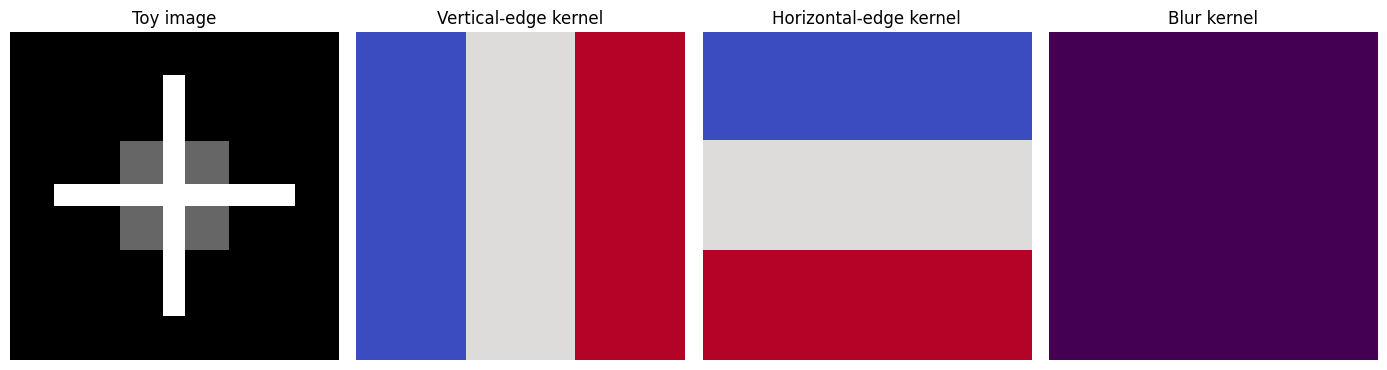

In [3]:

# A simple toy image: a bright cross on a dark background
img = np.zeros((15, 15), dtype=float)
img[2:13, 7] = 1.0
img[7, 2:13] = 1.0
img[5:10, 5:10] += 0.4
img = np.clip(img, 0, 1)

k_vertical = np.array([[-1, 0, 1],
                       [-1, 0, 1],
                       [-1, 0, 1]], dtype=float)

k_horizontal = np.array([[-1, -1, -1],
                         [ 0,  0,  0],
                         [ 1,  1,  1]], dtype=float)

k_blur = (1/9) * np.ones((3, 3), dtype=float)

plot_images(
    [img, k_vertical, k_horizontal, k_blur],
    titles=['Toy image', 'Vertical-edge kernel', 'Horizontal-edge kernel', 'Blur kernel'],
    cmaps=['gray', 'coolwarm', 'coolwarm', 'viridis'],
    figsize=(14, 3.6)
)


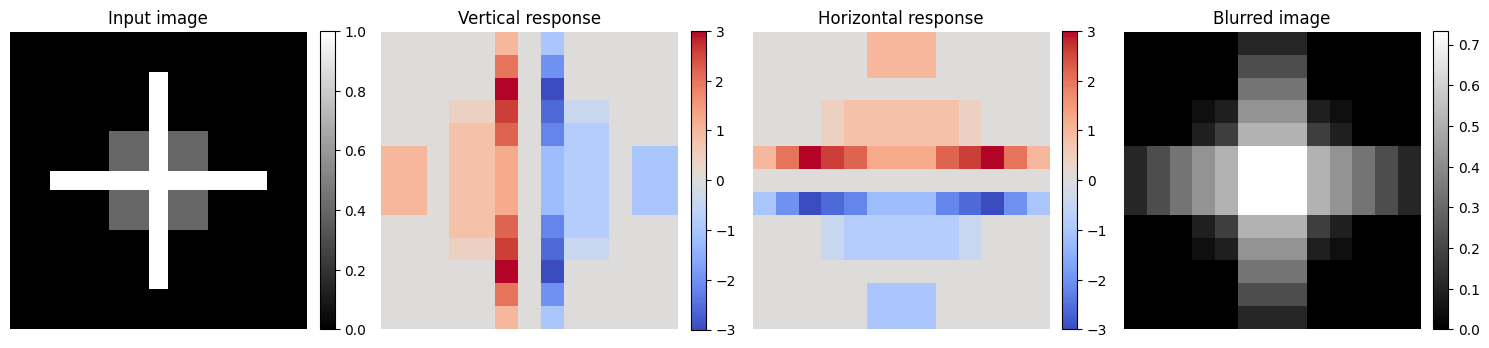

In [4]:

feat_vertical = conv2d_valid(img, k_vertical)
feat_horizontal = conv2d_valid(img, k_horizontal)
feat_blur = conv2d_valid(img, k_blur)

plot_images(
    [img, feat_vertical, feat_horizontal, feat_blur],
    titles=['Input image', 'Vertical response', 'Horizontal response', 'Blurred image'],
    cmaps=['gray', 'coolwarm', 'coolwarm', 'gray'],
    figsize=(15, 3.8),
    colorbar=True
)



### Things to try
- Flip the sign of one kernel. What changes?
- Replace the cross by a square or a diagonal line.
- Change the blur filter to a sharpen filter, for example
  \[
  \begin{bmatrix}
  0 & -1 & 0 \\
  -1 & 5 & -1 \\
  0 & -1 & 0
  \end{bmatrix}.
  \]
  



---
## Exercise 2: Edge detection on a real image

Now let us use a real photograph. `scikit-learn` ships with a colorful sample image called **china.jpg**.

### Task
1. Convert the image to grayscale.
2. Use the Sobel-style filters `Kx` and `Ky` to compute horizontal and vertical edge responses.
3. Combine them into a single edge-strength map
   \[
   \text{edge\_strength} = \sqrt{g_x^2 + g_y^2}.
   \]
4. Apply a small `2 \times 2` max-pooling step to the edge map and compare before versus after.


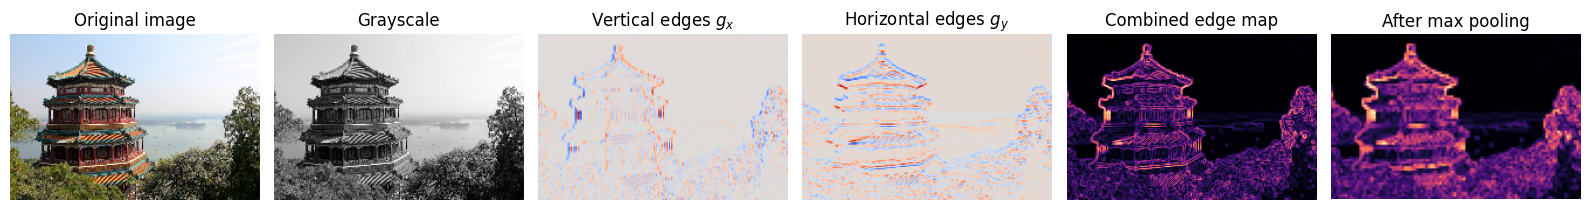

In [7]:

china = load_sample_image('china.jpg') / 255.0
china = china[::3, ::3]  # downsample for speed

gray = 0.299 * china[:, :, 0] + 0.587 * china[:, :, 1] + 0.114 * china[:, :, 2]

Kx = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]], dtype=float)
Ky = np.array([[-1, -2, -1],
               [ 0,  0,  0],
               [ 1,  2,  1]], dtype=float)

gx = conv2d_valid(gray, Kx)
gy = conv2d_valid(gray, Ky)
edge_strength = np.sqrt(gx**2 + gy**2)
edge_strength = edge_strength / edge_strength.max()
pooled_edges = max_pool2d(edge_strength, pool=2, stride=2)

plot_images(
    [china, gray, gx, gy, edge_strength, pooled_edges],
    titles=['Original image', 'Grayscale', 'Vertical edges $g_x$', 'Horizontal edges $g_y$', 'Combined edge map', 'After max pooling'],
    cmaps=[None, 'gray', 'coolwarm', 'coolwarm', 'magma', 'magma'],
    figsize=(16, 7),
    colorbar=False
)



### Things to try
- Replace `china.jpg` with `flower.jpg` using `load_sample_image('flower.jpg')`.
- Compare max pooling with simple average pooling.
- Try the blur or sharpen kernels from Exercise 1 on the grayscale photo.



---
## Exercise 3: A tiny CNN for handwritten digits

We now train a very small CNN on the built-in `digits` dataset from `scikit-learn`.
Each image is only `8 \times 8`, so training is fast.

### Task
1. Build a CNN with the following structure:
   - `Conv(1 -> 8, kernel=3, padding=1)`
   - `ReLU`
   - `MaxPool(2)`
   - `Conv(8 -> 16, kernel=3, padding=1)`
   - `ReLU`
   - `MaxPool(2)`
   - `Flatten`
   - `Linear(16 * 2 * 2 -> 10)`
2. Train it for a few epochs.
3. Visualize the training curves, a few predictions, and the learned first-layer filters.


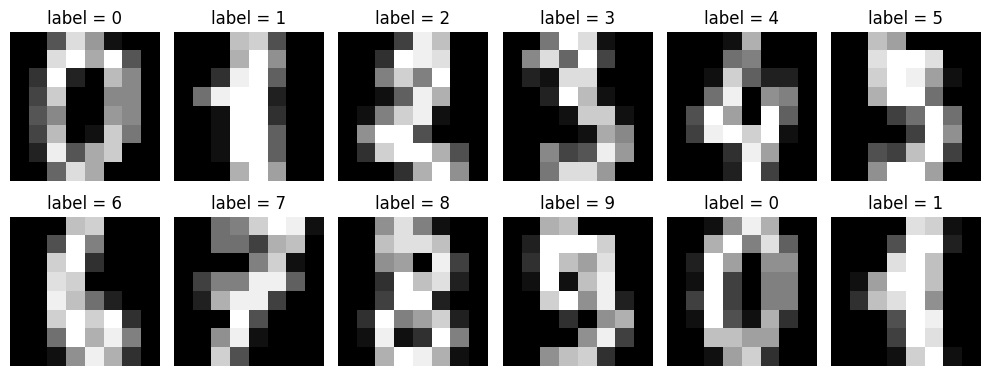

Train set: torch.Size([1347, 1, 8, 8]) torch.Size([1347])
Test set:  torch.Size([450, 1, 8, 8]) torch.Size([450])


In [8]:

# Load digits: 1797 grayscale images of size 8x8
digits = load_digits()
X = digits.images.astype(np.float32) / 16.0
y = digits.target.astype(np.int64)

# Quick visual check: a few examples
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, idx in zip(axes.ravel(), range(12)):
    ax.imshow(X[idx], cmap='gray')
    ax.set_title(f'label = {y[idx]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

X_train_t = torch.tensor(X_train[:, None, :, :], dtype=torch.float32)
X_test_t  = torch.tensor(X_test[:, None, :, :], dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=256, shuffle=False)

print('Train set:', X_train_t.shape, y_train_t.shape)
print('Test set: ', X_test_t.shape, y_test_t.shape)


In [10]:

class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.fc = nn.Linear(16 * 2 * 2, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.max_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

model = TinyCNN()
print(model)


# Input:              1 x 8 x 8
# Conv1:              8 x 8 x 8
# MaxPool:            8 x 4 x 4
# Conv2:             16 x 4 x 4  , filter shapes are 8 x 3 x 3
# MaxPool:           16 x 2 x 2
# Flatten:           64
# Linear:            10


TinyCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc): Linear(in_features=64, out_features=10, bias=True)
)


In [11]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

history_loss = []
history_acc = []

def accuracy(loader, model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += len(yb)
    return correct / total

for epoch in range(4):
    model.train()
    running_loss = 0.0
    n_seen = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(yb)
        n_seen += len(yb)

    epoch_loss = running_loss / n_seen
    epoch_acc = accuracy(test_loader, model)
    history_loss.append(epoch_loss)
    history_acc.append(epoch_acc)
    print(f'Epoch {epoch+1:02d}: loss = {epoch_loss:.4f}, test accuracy = {epoch_acc:.3f}')


Epoch 01: loss = 2.0385, test accuracy = 0.669
Epoch 02: loss = 0.8368, test accuracy = 0.887
Epoch 03: loss = 0.3120, test accuracy = 0.922
Epoch 04: loss = 0.2205, test accuracy = 0.933


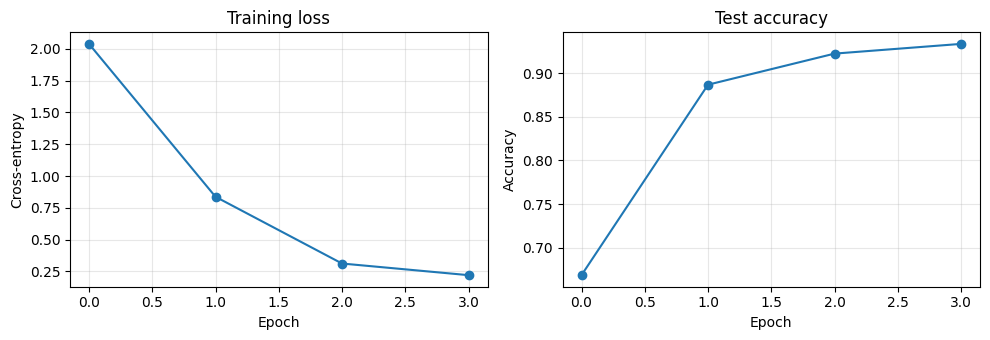

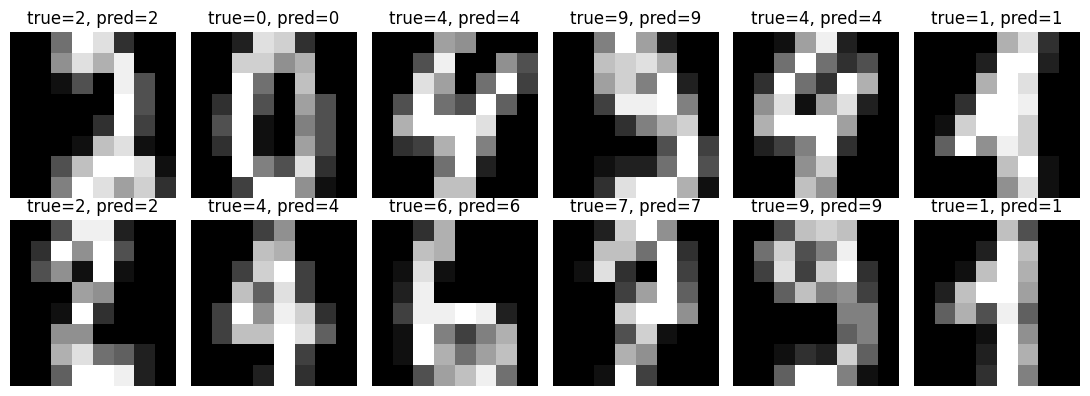

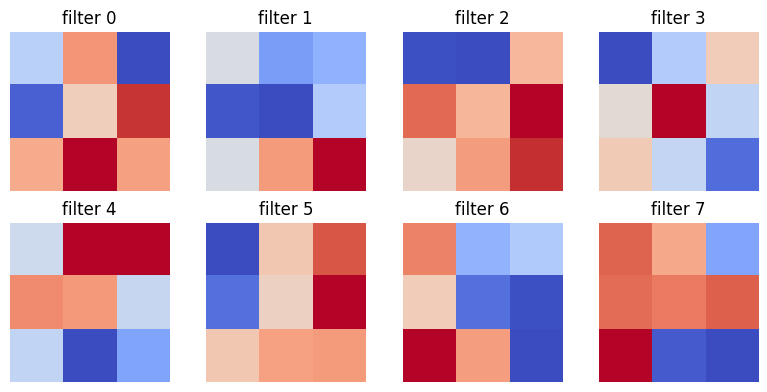

In [12]:

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history_loss, marker='o')
axes[0].set_title('Training loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy')
axes[0].grid(alpha=0.3)

axes[1].plot(history_acc, marker='o')
axes[1].set_title('Test accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Predictions on 12 test images
model.eval()
with torch.no_grad():
    logits = model(X_test_t[:12].to(device))
    preds = logits.argmax(dim=1).cpu().numpy()

fig, axes = plt.subplots(2, 6, figsize=(11, 4))
for ax, img, true_y, pred_y in zip(axes.ravel(), X_test[:12], y_test[:12], preds):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'true={true_y}, pred={pred_y}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Visualize learned filters from the first convolution
weights = model.conv1.weight.detach().cpu().numpy()
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for ax, w, k in zip(axes.ravel(), weights, range(len(weights))):
    ax.imshow(w[0], cmap='coolwarm')
    ax.set_title(f'filter {k}')
    ax.axis('off')
plt.tight_layout()
plt.show()



### Things to try
- Train for more epochs. How high does the test accuracy go?
- Change the number of filters from `8,16` to `16,32`.
- Remove one ReLU. Does the model still work as well?
- Compare the CNN with a simple fully connected network on the same dataset.
